# MeGA-IA Experiments Notebook
### Systematic Improvement Study: Fitness Function · Search Budget · Penalty Ablation

This notebook runs **10 MeGA-IA variants** across three improvement tiers and compares them all on the Deepfake-Eval-2024 test set.

| Tier | Experiments | What changes |
|------|-------------|-------------|
| **Tier 1** | E01–E04 | Fitness function (accuracy → AUC → balanced), λ tuning |
| **Tier 2** | E05–E07 | Search budget: more gens/pop, diversity injection, 3-segment alpha genome |
| **Tier 3** | E08–E10 | Penalty ablation: CKA-only, Entropy-only, Multi-layer CKA |

**Checkpointing**: Every generation is checkpointed. You can interrupt and resume freely.  
**Logging**: Every candidate evaluation prints live metrics during fitness computation.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess, sys
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q',
    'tqdm', 'soundfile', 'scikit-learn', 'scipy', 'librosa', 'matplotlib', 'seaborn'
])
print('✅ Dependencies ready.')


Mounted at /content/drive
✅ Dependencies ready.


In [ ]:
import os, sys, time, copy, json, random, datetime, warnings, math
import numpy as np
import pandas as pd
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import librosa
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.metrics import (
    roc_auc_score, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc as sk_auc
)

torch.manual_seed(0)
np.random.seed(0)
print('✅ All imports successful.')


✅ All imports successful.


In [ ]:
# ── Logging ───────────────────────────────────────────────────────────────────
ICONS = {'INFO': '  ', 'OK': '✅', 'WARN': '⚠️ ', 'ERR': '❌', 'HEAD': '🔷', 'STAR': '⭐'}

def log(msg, level='INFO'):
    ts = datetime.datetime.now().strftime('%H:%M:%S')
    icon = ICONS.get(level, '  ')
    print(f'[{ts}] {icon} {msg}')

# ── Checkpoint helpers ─────────────────────────────────────────────────────────
def save_exp_results(ckpt_dir, exp_id, best_val_metrics, history, best_genome):
    data = {
        'completed': True,
        'timestamp': datetime.datetime.now().isoformat(),
        'best_val_metrics': best_val_metrics,
        'history': history,
        'best_genome': best_genome.tolist() if isinstance(best_genome, np.ndarray) else best_genome,
    }
    with open(os.path.join(ckpt_dir, f'{exp_id}_results.json'), 'w') as f:
        json.dump(data, f, indent=2)

def load_exp_results(ckpt_dir, exp_id):
    rpath = os.path.join(ckpt_dir, f'{exp_id}_results.json')
    wpath = os.path.join(ckpt_dir, f'{exp_id}_best_weights.pth')
    if os.path.exists(rpath) and os.path.exists(wpath):
        with open(rpath) as f:
            d = json.load(f)
        if d.get('completed'):
            return d
    return None

def save_test_results(ckpt_dir, exp_id, test_metrics):
    data = {'completed': True, 'timestamp': datetime.datetime.now().isoformat(),
            'test_metrics': test_metrics}
    with open(os.path.join(ckpt_dir, f'{exp_id}_test_results.json'), 'w') as f:
        json.dump(data, f, indent=2)

def load_test_results(ckpt_dir, exp_id):
    path = os.path.join(ckpt_dir, f'{exp_id}_test_results.json')
    if os.path.exists(path):
        with open(path) as f:
            d = json.load(f)
        if d.get('completed'):
            return d['test_metrics']
    return None

log('Logger + checkpoint utilities ready.', 'OK')


[14:13:15] ✅ Logger + checkpoint utilities ready.


In [ ]:
# ══ CHANGE THESE IF YOUR PATHS DIFFER ═══════════════════════════════════════
WORKING_DIR    = "/content/drive/My Drive/ANN/ANN"
CKPT1          = "rawnet2-antispoofing/models/model_logical_weighted_CCE_25_32_0.0001_full_seed/checkpoint_ep025.pth"
CKPT2          = "rawnet2-antispoofing/models/model_logical_weighted_CCE_25_32_0.0001_seed9999_checkpoints/checkpoint_ep025.pth"
XMAD_PATH      = "Datasets/XMAD-Bench: Cross-Domain Multilingual Audio Deepfake Benchmark"
DEEPFAKE_PATH  = "Datasets/Deepfake-Evals-2024/audio"
BATCH_SIZE     = 16
# ════════════════════════════════════════════════════════════════════════════

CHECKPOINT_DIR = os.path.join(WORKING_DIR, "mega_ia_experiments")

if not os.path.isdir(WORKING_DIR):
    raise FileNotFoundError(f"❌ WORKING_DIR not found: {WORKING_DIR}")

os.chdir(WORKING_DIR)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

for label, path in [('Checkpoint 1', CKPT1), ('Checkpoint 2', CKPT2)]:
    if not os.path.isfile(path):
        raise FileNotFoundError(f'❌ {label} not found: {os.path.abspath(path)}')
    log(f'{label}: {os.path.getsize(path)/1e6:.1f} MB  ✓')

for label, path in [('XMAD dir', XMAD_PATH), ('Deepfake dir', DEEPFAKE_PATH)]:
    if not os.path.isdir(path):
        raise FileNotFoundError(f'❌ {label} not found')
    log(f'{label} found ✓')

log(f'Experiment outputs → {CHECKPOINT_DIR}', 'OK')


[14:13:18]    Checkpoint 1: 305.4 MB  ✓
[14:13:18]    Checkpoint 2: 305.4 MB  ✓
[14:13:18]    XMAD dir found ✓
[14:13:19]    Deepfake dir found ✓
[14:13:19] ✅ Experiment outputs → /content/drive/My Drive/ANN/ANN/mega_ia_experiments


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
log(f'Device: {device.upper()}')
if device == 'cuda':
    props = torch.cuda.get_device_properties(0)
    free  = (props.total_memory - torch.cuda.memory_allocated()) / 1e9
    log(f'GPU: {props.name} | Total: {props.total_memory/1e9:.1f} GB | Free: {free:.1f} GB')
else:
    log('No GPU — CPU mode (very slow for large experiments)', 'WARN')


[14:13:19]    Device: CUDA
[14:13:19]    GPU: Tesla T4 | Total: 15.6 GB | Free: 15.6 GB


## RawNet2 Architecture

In [ ]:
class SincConv(nn.Module):
    def __init__(self, device, out_channels, kernel_size, sample_rate=16000):
        super().__init__()
        self.out_channels = out_channels + 1
        self.kernel_size   = kernel_size if kernel_size % 2 != 0 else kernel_size + 1
        self.device        = device
        self.sample_rate   = sample_rate
        f          = int(self.sample_rate / 2) * np.linspace(0, 1, 257)
        fmel       = 2595 * np.log10(1 + f / 700)
        filbw      = 700 * (10 ** (np.linspace(np.min(fmel), np.max(fmel), self.out_channels + 2) / 2595) - 1)
        self.freq  = filbw[:self.out_channels]
        self.hsupp = torch.arange(-(self.kernel_size-1)/2, (self.kernel_size-1)/2 + 1)
        self.band_pass = torch.zeros(self.out_channels - 1, self.kernel_size)

    def forward(self, x):
        for i in range(len(self.freq) - 1):
            fmin, fmax = self.freq[i], self.freq[i+1]
            hH = (2*fmax/self.sample_rate) * np.sinc(2*fmax*self.hsupp/self.sample_rate)
            hL = (2*fmin/self.sample_rate) * np.sinc(2*fmin*self.hsupp/self.sample_rate)
            self.band_pass[i, :] = torch.Tensor(np.hamming(self.kernel_size)) * torch.Tensor(hH - hL)
        filt = self.band_pass.to(self.device).view(self.out_channels-1, 1, self.kernel_size)
        return F.conv1d(x, filt, stride=1, padding=0)


class Residual_block(nn.Module):
    def __init__(self, nb_filts, first=False):
        super().__init__()
        self.first = first
        if not self.first:
            self.bn1 = nn.BatchNorm1d(num_features=nb_filts[0])
        self.lrelu = nn.LeakyReLU(negative_slope=0.3)
        self.conv1 = nn.Conv1d(nb_filts[0], nb_filts[1], kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm1d(num_features=nb_filts[1])
        self.conv2 = nn.Conv1d(nb_filts[1], nb_filts[1], kernel_size=3, padding=1)
        self.downsample = nb_filts[0] != nb_filts[1]
        if self.downsample:
            self.conv_downsample = nn.Conv1d(nb_filts[0], nb_filts[1], kernel_size=1)
        self.mp = nn.MaxPool1d(3)

    def forward(self, x):
        identity = x
        out = x if self.first else self.lrelu(self.bn1(x))
        out = self.conv2(self.lrelu(self.bn2(self.conv1(out))))
        if self.downsample:
            identity = self.conv_downsample(identity)
        out += identity
        return self.mp(out)


class RawNet(nn.Module):
    def __init__(self, d_args, device):
        super().__init__()
        self.device    = device
        self.Sinc_conv = SincConv(device=device, out_channels=d_args['filts'][0], kernel_size=d_args['first_conv'])
        self.first_bn  = nn.BatchNorm1d(num_features=d_args['filts'][0])
        self.selu      = nn.SELU(inplace=True)
        self.block0    = nn.Sequential(Residual_block(nb_filts=d_args['filts'][1], first=True))
        self.block1    = nn.Sequential(Residual_block(nb_filts=d_args['filts'][1]))
        self.block2    = nn.Sequential(Residual_block(nb_filts=d_args['filts'][2]))
        f2 = [d_args['filts'][2][1], d_args['filts'][2][1]]
        self.block3, self.block4, self.block5 = [nn.Sequential(Residual_block(nb_filts=f2)) for _ in range(3)]
        self.avgpool   = nn.AdaptiveAvgPool1d(1)
        self.fc_att    = nn.ModuleList(
            [nn.Linear(f, f) for f in [d_args['filts'][1][-1]]*2 + [d_args['filts'][2][-1]]*4])
        self.bn_before_gru = nn.BatchNorm1d(num_features=d_args['filts'][2][-1])
        self.gru = nn.GRU(input_size=d_args['filts'][2][-1], hidden_size=d_args['gru_node'],
                          num_layers=d_args['nb_gru_layer'], batch_first=True)
        self.fc1 = nn.Linear(d_args['gru_node'], d_args['nb_fc_node'])
        self.fc2 = nn.Linear(d_args['nb_fc_node'], d_args['nb_classes'])

    def forward(self, x, is_test=False):
        x = x.view(x.size(0), 1, -1)
        x = self.selu(self.first_bn(F.max_pool1d(torch.abs(self.Sinc_conv(x)), 3)))
        for i, block in enumerate([self.block0, self.block1, self.block2,
                                    self.block3, self.block4, self.block5]):
            x   = block(x)
            att = torch.sigmoid(self.fc_att[i](self.avgpool(x).view(x.size(0), -1)))
            att = att.view(x.size(0), x.size(1), -1)
            x   = x * att + att
        x = self.selu(self.bn_before_gru(x)).permute(0, 2, 1)
        self.gru.flatten_parameters()
        x, _ = self.gru(x)
        logits = self.fc2(self.fc1(x[:, -1, :]))
        return F.softmax(logits, dim=1) if is_test else logits


d_args = {
    'first_conv'  : 128,
    'filts'       : [128, [128, 128], [128, 512], [512, 512]],
    'nb_fc_node'  : 1024,
    'gru_node'    : 1024,
    'nb_gru_layer': 3,
    'nb_classes'  : 2,
}
log('RawNet2 architecture defined.', 'OK')


[14:13:19] ✅ RawNet2 architecture defined.


## Dataset Classes

In [ ]:
def pad_random(x, max_len=64600):
    x_len = x.shape[0]
    if x_len > max_len:
        stt = np.random.randint(x_len - max_len)
        return x[stt:stt + max_len]
    return np.tile(x, (int(max_len / x_len) + 1))[:max_len]


class XMADDataset(Dataset):
    """XMAD-Bench validation split — WAV only, soundfile."""
    def __init__(self, root_dir):
        self.root_dir = root_dir
        df = pd.read_csv(os.path.join(root_dir, 'meta_validation.csv'))
        self.df = df[df['split'] == 'val'].reset_index(drop=True)
        self.n_fake = int(self.df['is_fake'].sum())
        self.n_real = len(self.df) - self.n_fake

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        subdir = 'fake' if row['is_fake'] == 1 else 'real'
        path   = os.path.join(self.root_dir, subdir, row['sample_name'])
        x, _   = sf.read(path)
        if x.ndim > 1: x = x.mean(axis=1)
        label  = 0 if row['is_fake'] == 1 else 1  # 0=spoof, 1=bonafide
        return torch.FloatTensor(pad_random(x)), label


class DeepfakeEvalsDataset(Dataset):
    """Deepfake-Evals-2024 test set — mixed formats via librosa.

    Valid file indices are cached to CHECKPOINT_DIR/deepfake_valid_indices.json
    so the slow pre-flight only runs once across all sessions/accounts.
    """
    TARGET_SR = 16000

    def __init__(self, root_dir, cache_dir=None):
        self.root_dir = root_dir
        df = pd.read_csv(os.path.join(root_dir, 'audio-metadata-publish.csv'))
        df = df[df['Filename'].notna()].copy()
        df['Filename'] = df['Filename'].astype(str).str.strip()

        cache_path = os.path.join(cache_dir, 'deepfake_valid_indices.json') if cache_dir else None

        # ── Try loading cached valid indices first ─────────────────────────
        if cache_path and os.path.exists(cache_path):
            with open(cache_path) as f:
                cached = json.load(f)
            good = cached['good_indices']
            skip_count = cached.get('skip_count', 0)
            log(f'  ✅ Loaded cached file list ({len(good)} valid, {skip_count} skipped) — pre-flight skipped.')
        else:
            # ── Run pre-flight and cache result ───────────────────────────
            log('  Pre-flighting Deepfake-Evals files (runs once, then cached)...')
            log('  ⚠️  This may take a few minutes on first run. Subsequent runs skip this entirely.', 'WARN')
            good, skip = [], []
            total = len(df)
            for pos, (i, row) in enumerate(df.iterrows()):
                if pos % 100 == 0:
                    log(f'  Pre-flight progress: {pos}/{total} files checked...')
                path = os.path.join(root_dir, row['Filename'])
                if not os.path.isfile(path):
                    skip.append(row['Filename']); continue
                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter('ignore')
                        librosa.load(path, sr=None, mono=True, duration=0.1)
                    good.append(i)
                except Exception:
                    skip.append(row['Filename'])

            skip_count = len(skip)
            if skip_count:
                log(f'  Skipped {skip_count} unreadable files.', 'WARN')

            # Save cache so next session skips this entirely
            if cache_path:
                with open(cache_path, 'w') as f:
                    json.dump({'good_indices': good, 'skip_count': skip_count}, f)
                log(f'  📁 Valid file list cached → {cache_path}')

        self.df     = df.loc[good].reset_index(drop=True)
        self.n_real = int((self.df['Ground Truth'] == 'Real').sum())
        self.n_fake = len(self.df) - self.n_real

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        path = os.path.join(self.root_dir, str(row['Filename']))
        x, _ = librosa.load(path, sr=self.TARGET_SR, mono=True)
        label = 1 if row['Ground Truth'] == 'Real' else 0
        return torch.FloatTensor(pad_random(x)), label


log('Dataset classes defined.', 'OK')


[14:13:19] ✅ Dataset classes defined.


## Load Datasets (Full — No Subsampling)

In [ ]:
log('Loading XMAD-Bench validation set (full)...', 'HEAD')
xmad_ds = XMADDataset(XMAD_PATH)
log(f'XMAD: {len(xmad_ds):,} samples  ({xmad_ds.n_real:,} real / {xmad_ds.n_fake:,} fake)')

log('Loading Deepfake-Eval-2024 test set (full)...', 'HEAD')
deepfake_ds = DeepfakeEvalsDataset(DEEPFAKE_PATH, cache_dir=CHECKPOINT_DIR)
log(f'Deepfake-Eval: {len(deepfake_ds):,} samples  ({deepfake_ds.n_real:,} real / {deepfake_ds.n_fake:,} fake)')

val_loader  = DataLoader(xmad_ds,     batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=(device=='cuda'))
test_loader = DataLoader(deepfake_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=(device=='cuda'))

log(f'Val loader : {len(val_loader):,} batches', 'OK')
log(f'Test loader: {len(test_loader):,} batches', 'OK')

# Smoke-test
log('Smoke-testing loaders...')
xb, yb = next(iter(val_loader))
log(f'Val  batch: {tuple(xb.shape)} labels sample={yb[:4].tolist()}')
xb, yb = next(iter(test_loader))
log(f'Test batch: {tuple(xb.shape)} labels sample={yb[:4].tolist()}')
del xb, yb
log('Both loaders confirmed.', 'OK')


[14:13:19] 🔷 Loading XMAD-Bench validation set (full)...
[14:13:21]    XMAD: 2,121 samples  (1,058 real / 1,063 fake)
[14:13:21] 🔷 Loading Deepfake-Eval-2024 test set (full)...
[14:13:30]      ✅ Loaded cached file list (1980 valid, 0 skipped) — pre-flight skipped.
[14:13:30]    Deepfake-Eval: 1,980 samples  (1,167 real / 813 fake)
[14:13:30] ✅ Val loader : 133 batches
[14:13:30] ✅ Test loader: 124 batches
[14:13:30]    Smoke-testing loaders...
[14:14:13]    Val  batch: (16, 64600) labels sample=[1, 0, 1, 0]


/tmp/ipykernel_481/3308121763.py:92: UserWarning: PySoundFile failed. Trying audioread instead.
  x, _ = librosa.load(path, sr=self.TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_481/3308121763.py:92: UserWarning: PySoundFile failed. Trying audioread instead.
  x, _ = librosa.load(path, sr=self.TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


[14:15:01]    Test batch: (16, 64600) labels sample=[1, 1, 0, 1]
[14:15:01] ✅ Both loaders confirmed.


## Load Parent Checkpoints

In [ ]:
def fix_state_dict(sd):
    """Translate checkpoint keys from model.py naming to notebook RawNet naming."""
    new = {}
    for k, v in sd.items():
        if 'fc_attention' in k:
            k = k.replace('fc_attention', 'fc_att.')
            k = k.replace('.0.', '.')
        elif 'fc1_gru' in k:
            k = k.replace('fc1_gru', 'fc1')
        elif 'fc2_gru' in k:
            k = k.replace('fc2_gru', 'fc2')
        new[k] = v
    return new

log('Loading parent checkpoints...')
ckpt1 = torch.load(CKPT1, map_location=device)
p1_state = fix_state_dict(ckpt1['model_state_dict'])
log(f'Parent 1 loaded: {len(p1_state)} keys')

ckpt2 = torch.load(CKPT2, map_location=device)
p2_state = fix_state_dict(ckpt2['model_state_dict'])
log(f'Parent 2 loaded: {len(p2_state)} keys')

assert set(p1_state.keys()) == set(p2_state.keys()), '❌ Architecture key mismatch!'

# Validate keys against live model
_probe = RawNet(d_args, device).to(device)
missing = set(_probe.state_dict().keys()) - set(p1_state.keys())
extra   = set(p1_state.keys()) - set(_probe.state_dict().keys())
del _probe
if missing or extra:
    raise RuntimeError(f'Key mismatch! Missing: {missing}  Extra: {extra}')

log('Both parents loaded and keys verified.', 'OK')


[14:15:01]    Loading parent checkpoints...
[14:15:10]    Parent 1 loaded: 119 keys
[14:15:20]    Parent 2 loaded: 119 keys
[14:15:20] ✅ Both parents loaded and keys verified.


## Core Utilities: Feature Extraction, CKA, Metrics

In [ ]:
def compute_linear_cka(x: torch.Tensor, y: torch.Tensor) -> float:
    """Linear Centred Kernel Alignment. Both tensors: (N, D) on CPU."""
    x = x - x.mean(0)
    y = y - y.mean(0)
    num   = torch.norm(torch.matmul(x.t(), y)) ** 2
    denom = (torch.norm(torch.matmul(x.t(), x)) *
             torch.norm(torch.matmul(y.t(), y)) + 1e-8)
    return (num / denom).item()


def extract_reference_features(model, loader, device):
    """
    Extract features from 3 network depths for use as parent-1 reference.
    Returns dict: 'early' (after block1), 'mid' (after block3), 'final' (GRU last step).
    All tensors shape (N, D), CPU.
    """
    model.eval()
    fe, fm, ff = [], [], []

    def h_early(m, inp, out):
        fe.append(F.adaptive_avg_pool1d(out.detach().cpu(), 1).squeeze(-1))
    def h_mid(m, inp, out):
        fm.append(F.adaptive_avg_pool1d(out.detach().cpu(), 1).squeeze(-1))
    def h_gru(m, inp, out):
        seq, _ = out
        ff.append(seq[:, -1, :].detach().cpu())

    hooks = [
        model.block1.register_forward_hook(h_early),
        model.block3.register_forward_hook(h_mid),
        model.gru.register_forward_hook(h_gru),
    ]
    with torch.no_grad():
        for x, _ in tqdm(loader, desc='  Extracting P1 features', leave=False):
            model(x.to(device), is_test=True)
    for h in hooks: h.remove()

    return {
        'early': torch.cat(fe),   # (N, 128)
        'mid':   torch.cat(fm),   # (N, 512)
        'final': torch.cat(ff),   # (N, 1024)
    }


def full_metrics(labels, preds, scores):
    """Compute all evaluation metrics given labels, hard preds, and soft scores."""
    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel() if cm.shape == (2,2) else (0,0,0,0)
    return {
        'accuracy'    : float(accuracy_score(labels, preds)),
        'auc'         : float(roc_auc_score(labels, scores)),
        'bal_acc'     : float(balanced_accuracy_score(labels, preds)),
        'precision'   : float(precision_score(labels, preds, zero_division=0)),
        'recall'      : float(recall_score(labels, preds, zero_division=0)),
        'f1'          : float(f1_score(labels, preds, zero_division=0)),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'confusion_matrix': cm.tolist(),
    }


log('Core utilities defined.', 'OK')


[14:15:20] ✅ Core utilities defined.


In [ ]:
def evaluate_candidate(model, loader, device, p1_feats, config):
    """
    Evaluate one candidate model on the FULL validation set.
    Logs live metrics for every call.
    Returns (metrics_dict, fitness_score).
    """
    model.eval()
    all_scores, all_labels = [], []
    cf_e, cf_m, cf_f = [], [], []   # child features: early, mid, final

    def h_e(m, inp, out): cf_e.append(F.adaptive_avg_pool1d(out.detach().cpu(), 1).squeeze(-1))
    def h_m(m, inp, out): cf_m.append(F.adaptive_avg_pool1d(out.detach().cpu(), 1).squeeze(-1))
    def h_g(m, inp, out):
        seq, _ = out
        cf_f.append(seq[:, -1, :].detach().cpu())

    hooks = [
        model.block1.register_forward_hook(h_e),
        model.block3.register_forward_hook(h_m),
        model.gru.register_forward_hook(h_g),
    ]
    with torch.no_grad():
        for x, y in loader:
            out = model(x.to(device), is_test=True)
            all_scores.append(out[:, 1].cpu().numpy())
            all_labels.append(y.numpy())
    for h in hooks: h.remove()

    scores = np.concatenate(all_scores)
    labels = np.concatenate(all_labels)
    preds  = (scores > 0.5).astype(int)

    feat_f = torch.cat(cf_f)   # (N, 1024)
    feat_e = torch.cat(cf_e)   # (N, 128)
    feat_m = torch.cat(cf_m)   # (N, 512)

    # ── Metrics ──────────────────────────────────────────────────────────
    met = full_metrics(labels, preds, scores)
    met['scores'] = scores.tolist()
    met['labels'] = labels.tolist()

    # ── Entropy penalty ───────────────────────────────────────────────────
    # Normalize by log2(2)=1 since binary, so range stays [0,1]
    p_mat = np.stack([1 - scores, scores], axis=1).clip(1e-8, 1 - 1e-8)
    met['entropy'] = float(-np.mean(np.sum(p_mat * np.log2(p_mat), axis=1)))

    # ── CKA penalty ───────────────────────────────────────────────────────
    cka_mode = config.get('cka_mode', 'final')
    if cka_mode == 'multilayer':
        cka_e = compute_linear_cka(feat_e, p1_feats['early'])
        cka_m = compute_linear_cka(feat_m, p1_feats['mid'])
        cka_f = compute_linear_cka(feat_f, p1_feats['final'])
        # Weighted: later layers matter more for task-specific features
        cka_score = 0.20 * cka_e + 0.30 * cka_m + 0.50 * cka_f
        met['cka_early'] = float(cka_e)
        met['cka_mid']   = float(cka_m)
        met['cka_final'] = float(cka_f)
    else:
        cka_score = compute_linear_cka(feat_f, p1_feats['final'])
    met['cka'] = float(cka_score)
    met['interference'] = float(1.0 - cka_score)

    # ── Composite fitness ─────────────────────────────────────────────────
    ft_type = config.get('fitness_type', 'accuracy')
    base = {'accuracy': met['accuracy'], 'auc': met['auc'], 'balanced': met['bal_acc']}[ft_type]
    fitness = base - config['lambda1'] * met['interference'] - config['lambda2'] * met['entropy']
    met['fitness'] = float(fitness)

    return met, float(fitness)


log('evaluate_candidate() defined.', 'OK')


[14:15:20] ✅ evaluate_candidate() defined.


## MeGA-IA Evolutionary Engine

In [ ]:
def run_mega_ia(config, p1_state, p2_state, d_args, device,
                val_loader, p1_feats, checkpoint_dir):
    """
    Run one MeGA-IA experiment to completion with full checkpointing.

    alpha_mode:
      'global'   — single alpha scalar (original)
      'segment3' — 3 independent alphas (early / mid / late layers)

    Returns (best_val_metrics, history, best_genome).
    """
    exp_id      = config['id']
    evo_ckpt    = os.path.join(checkpoint_dir, f'{exp_id}_evo_state.json')
    weights_pth = os.path.join(checkpoint_dir, f'{exp_id}_best_weights.pth')

    # ── Genome setup ──────────────────────────────────────────────────────
    float_keys = [k for k in p1_state.keys()
                  if p1_state[k].dtype.is_floating_point]
    n_fl = len(float_keys)
    all_keys = list(p1_state.keys())

    alpha_mode  = config.get('alpha_mode', 'global')
    genome_size = 1 if alpha_mode == 'global' else 3

    def make_model(genome):
        m = RawNet(d_args, device).to(device)
        sd, fi = {}, 0
        for k in all_keys:
            v1 = p1_state[k].to(device)
            v2 = p2_state[k].to(device)
            if not v1.dtype.is_floating_point:
                sd[k] = v1.clone()
            else:
                if alpha_mode == 'global':
                    a = float(genome[0])
                else:  # segment3
                    seg = min(fi * 3 // n_fl, 2)
                    a = float(genome[seg])
                sd[k] = a * v1 + (1.0 - a) * v2
                fi += 1
        m.load_state_dict(sd)
        return m

    def rnd_genome():
        return np.random.uniform(0.0, 1.0, genome_size)

    def crossover(g1, g2):
        mask = np.random.rand(genome_size) < 0.5
        return np.where(mask, g1, g2)

    def mutate(genome, gen):
        decay = math.exp(-0.5 * gen / max(config['generations'], 1))
        sigma = config.get('sigma_base', 0.10) * decay
        return np.clip(genome + np.random.normal(0, sigma, genome_size), 0.0, 1.0)

    def tournament(pop, fits, k=4):
        idx = np.random.choice(len(pop), min(k, len(pop)), replace=False)
        best_i = idx[np.argmax([fits[i] for i in idx])]
        return pop[best_i].copy()

    # ── Initialize / resume ───────────────────────────────────────────────
    start_gen       = 0
    population      = [rnd_genome() for _ in range(config['pop_size'])]
    best_genome     = population[0].copy()
    best_fitness    = -np.inf
    best_val_met    = None
    stagnation      = 0
    hist_keys = ['best_fit','mean_fit','worst_fit','best_auc','best_bal',
                 'best_f1','mean_auc','diversity','best_prec','best_rec']
    history = {k: [] for k in hist_keys}

    if os.path.exists(evo_ckpt):
        try:
            with open(evo_ckpt) as f: ec = json.load(f)
            start_gen    = ec['last_gen'] + 1
            population   = [np.array(g) for g in ec['population']]
            best_genome  = np.array(ec['best_genome'])
            best_fitness = ec['best_fitness']
            best_val_met = ec.get('best_val_met')
            stagnation   = ec.get('stagnation', 0)
            history      = ec['history']
            log(f'  ♻️  Resumed from gen {start_gen}', 'WARN')
        except Exception as e:
            log(f'  Evo checkpoint corrupt ({e}) — starting fresh', 'WARN')

    total_gens = config['generations']
    pop_sz     = config['pop_size']

    # ── Evolutionary loop ─────────────────────────────────────────────────
    for gen in range(start_gen, total_gens):
        t0 = time.time()
        sep = '─' * 50
        log(f'')
        log(f'┌─ [{config["name"]}]  Gen {gen+1:2d}/{total_gens}  {sep[:30]}')

        gen_fits = []
        gen_mets = []

        for ci, genome in enumerate(population):
            model = make_model(genome)
            met, fit = evaluate_candidate(model, val_loader, device, p1_feats, config)
            gen_fits.append(fit)
            gen_mets.append(met)
            del model
            if device == 'cuda': torch.cuda.empty_cache()

            # ── Live candidate log ────────────────────────────────────────
            log(f'│ [{ci+1:2d}/{pop_sz}] '
                f'fit={fit:+.4f}  AUC={met["auc"]:.4f}  '
                f'bal={met["bal_acc"]:.4f}  F1={met["f1"]:.4f}  '
                f'rec={met["recall"]:.4f}  prec={met["precision"]:.4f}  '
                f'CKA={met["cka"]:.4f}  ent={met["entropy"]:.4f}')

        # ── Generation summary ────────────────────────────────────────────
        gen_best_i  = int(np.argmax(gen_fits))
        gen_best_f  = gen_fits[gen_best_i]
        gen_best_m  = gen_mets[gen_best_i]
        mean_fit    = float(np.mean(gen_fits))
        worst_fit   = float(np.min(gen_fits))
        mean_auc    = float(np.mean([m['auc'] for m in gen_mets]))
        # Diversity: std of all genome values flattened
        diversity   = float(np.std(np.vstack(population)))

        improved = gen_best_f > best_fitness
        if improved:
            best_fitness = gen_best_f
            best_genome  = population[gen_best_i].copy()
            best_val_met = {k: v for k, v in gen_best_m.items()
                            if k not in ('scores', 'labels')}
            bm = make_model(best_genome)
            torch.save(bm.state_dict(), weights_pth)
            del bm
            if device == 'cuda': torch.cuda.empty_cache()
            stagnation = 0
        else:
            stagnation += 1

        history['best_fit'].append(float(gen_best_f))
        history['mean_fit'].append(mean_fit)
        history['worst_fit'].append(worst_fit)
        history['best_auc'].append(float(gen_best_m['auc']))
        history['best_bal'].append(float(gen_best_m['bal_acc']))
        history['best_f1'].append(float(gen_best_m['f1']))
        history['mean_auc'].append(mean_auc)
        history['diversity'].append(diversity)
        history['best_prec'].append(float(gen_best_m['precision']))
        history['best_rec'].append(float(gen_best_m['recall']))

        star = ' ⭐ NEW BEST' if improved else ''
        log(f'├─ Gen summary  best={gen_best_f:.4f}  mean={mean_fit:.4f}  '
            f'worst={worst_fit:.4f}  div={diversity:.4f}  ({time.time()-t0:.0f}s){star}')
        log(f'│  Gen best cand:  AUC={gen_best_m["auc"]:.4f}  '
            f'bal={gen_best_m["bal_acc"]:.4f}  F1={gen_best_m["f1"]:.4f}')
        log(f'│  Global best:    fit={best_fitness:.4f}  stagnation={stagnation} gen(s)')
        if best_genome is not None and len(best_genome) <= 3:
            log(f'│  Best genome:    {[f"{v:.3f}" for v in best_genome]}')

        # ── Diversity injection ───────────────────────────────────────────
        if (config.get('diversity_injection') and
                stagnation >= config.get('diversity_patience', 5)):
            n_inj   = max(1, pop_sz // 4)
            worst_i = np.argsort(gen_fits)[:n_inj]
            for wi in worst_i:
                population[wi] = rnd_genome()
            log(f'│  💉 Diversity injection: replaced {n_inj} worst candidates (stagnation reset)')
            stagnation = 0

        # ── Selection + reproduction ──────────────────────────────────────
        new_pop = [best_genome.copy()]   # elitism
        while len(new_pop) < pop_sz:
            pa    = tournament(population, gen_fits)
            pb    = tournament(population, gen_fits)
            child = crossover(pa, pb)
            if np.random.rand() < 0.20:
                child = mutate(child, gen)
            new_pop.append(child)
        population = new_pop

        # ── Save mid-run checkpoint ───────────────────────────────────────
        ec_out = {
            'last_gen': gen,
            'population': [g.tolist() for g in population],
            'best_genome': best_genome.tolist(),
            'best_fitness': float(best_fitness),
            'best_val_met': best_val_met,
            'stagnation': stagnation,
            'history': history,
        }
        with open(evo_ckpt, 'w') as f:
            json.dump(ec_out, f)
        log(f'└─ Gen {gen+1} complete. Checkpoint saved.  [next: gen {gen+2}]')

    log(f'')
    log(f'🏆 [{config["name"]}] Evolution finished!')
    log(f'   Best fitness : {best_fitness:.4f}')
    log(f'   Best val AUC : {best_val_met["auc"]:.4f}')
    log(f'   Best val bal : {best_val_met["bal_acc"]:.4f}')
    log(f'   Best val F1  : {best_val_met["f1"]:.4f}')

    return best_val_met, history, best_genome


log('MeGA-IA engine defined.', 'OK')


[14:15:20] ✅ MeGA-IA engine defined.


## Experiment Configurations
10 experiments across 3 tiers. Each is self-contained and checkpointed.

| ID | Name | Tier | Key change |
|----|------|------|-----------|
| E01 | Original MeGA-IA | Tier 1 | Baseline reference |
| E02 | AUC Fitness | Tier 1 | `acc → AUC` in fitness |
| E03 | Balanced Acc Fitness | Tier 1 | `acc → balanced_acc` |
| E04 | AUC + Raised Penalties | Tier 1 | λ₁=0.3, λ₂=0.15 |
| E05 | Larger Budget | Tier 2 | 20 gens, pop=25 |
| E06 | Budget + Diversity | Tier 2 | + diversity injection |
| E07 | 3-Segment Alpha | Tier 2 | early/mid/late independent α |
| E08 | CKA Only | Tier 3 | λ₂=0 (ablate entropy) |
| E09 | Entropy Only | Tier 3 | λ₁=0 (ablate CKA) |
| E10 | Multi-Layer CKA | Tier 3 | CKA at 3 depths |


In [ ]:
EXPERIMENTS = [
    # ── Tier 1: Fitness Function ─────────────────────────────────────────
    dict(id='E01_original',      name='E01 Original MeGA-IA',
         group='Tier 1 — Fitness',
         fitness_type='accuracy', lambda1=0.10, lambda2=0.05,
         generations=5,  pop_size=10, alpha_mode='global',   cka_mode='final',
         diversity_injection=False, diversity_patience=5, sigma_base=0.10,
         description='Baseline — reproduces Assignment 3 MeGA-IA'),

    dict(id='E02_auc_fitness',   name='E02 AUC Fitness',
         group='Tier 1 — Fitness',
         fitness_type='auc',      lambda1=0.10, lambda2=0.05,
         generations=5,  pop_size=10, alpha_mode='global',   cka_mode='final',
         diversity_injection=False, diversity_patience=5, sigma_base=0.10,
         description='Replace accuracy with AUC — immune to predict-all-fake'),

    dict(id='E03_balanced',      name='E03 Balanced Acc Fitness',
         group='Tier 1 — Fitness',
         fitness_type='balanced', lambda1=0.10, lambda2=0.05,
         generations=5,  pop_size=10, alpha_mode='global',   cka_mode='final',
         diversity_injection=False, diversity_patience=5, sigma_base=0.10,
         description='(TPR+TNR)/2 — penalises class-imbalance exploitation'),

    dict(id='E04_raised_pen',    name='E04 AUC + Raised Penalties',
         group='Tier 1 — Fitness',
         fitness_type='auc',      lambda1=0.30, lambda2=0.15,
         generations=5,  pop_size=10, alpha_mode='global',   cka_mode='final',
         diversity_injection=False, diversity_patience=5, sigma_base=0.10,
         description='AUC fitness + stronger CKA (λ1=0.3) and entropy (λ2=0.15)'),

    # ── Tier 2: Search Budget ─────────────────────────────────────────────
    dict(id='E05_budget',        name='E05 Larger Budget',
         group='Tier 2 — Search Budget',
         fitness_type='auc',      lambda1=0.30, lambda2=0.15,
         generations=20, pop_size=25, alpha_mode='global',   cka_mode='final',
         diversity_injection=False, diversity_patience=5, sigma_base=0.10,
         description='Best T1 config + 20 generations + population 25'),

    dict(id='E06_diversity',     name='E06 Budget + Diversity',
         group='Tier 2 — Search Budget',
         fitness_type='auc',      lambda1=0.30, lambda2=0.15,
         generations=20, pop_size=25, alpha_mode='global',   cka_mode='final',
         diversity_injection=True,  diversity_patience=5, sigma_base=0.10,
         description='E05 + inject random candidates when stagnant for 5 gens'),

    dict(id='E07_seg3',          name='E07 3-Segment Alpha',
         group='Tier 2 — Search Budget',
         fitness_type='auc',      lambda1=0.30, lambda2=0.15,
         generations=20, pop_size=25, alpha_mode='segment3', cka_mode='final',
         diversity_injection=True,  diversity_patience=5, sigma_base=0.10,
         description='Per-segment genome: early/mid/late layers get independent mixing'),

    # ── Tier 3: Penalty Ablation ─────────────────────────────────────────
    dict(id='E08_cka_only',      name='E08 CKA Penalty Only',
         group='Tier 3 — Penalty Ablation',
         fitness_type='auc',      lambda1=0.50, lambda2=0.00,
         generations=20, pop_size=25, alpha_mode='global',   cka_mode='final',
         diversity_injection=True,  diversity_patience=5, sigma_base=0.10,
         description='AUC − λ1·CKA only; entropy term removed (λ2=0)'),

    dict(id='E09_entropy_only',  name='E09 Entropy Penalty Only',
         group='Tier 3 — Penalty Ablation',
         fitness_type='auc',      lambda1=0.00, lambda2=0.25,
         generations=20, pop_size=25, alpha_mode='global',   cka_mode='final',
         diversity_injection=True,  diversity_patience=5, sigma_base=0.10,
         description='AUC − λ2·Entropy only; CKA term removed (λ1=0)'),

    dict(id='E10_multilayer',    name='E10 Multi-Layer CKA',
         group='Tier 3 — Penalty Ablation',
         fitness_type='auc',      lambda1=0.30, lambda2=0.15,
         generations=20, pop_size=25, alpha_mode='segment3', cka_mode='multilayer',
         diversity_injection=True,  diversity_patience=5, sigma_base=0.10,
         description='CKA computed at early+mid+final layers; weighted 0.2+0.3+0.5'),
]

# Print overview
print(f'{"ID":<20} {"Group":<25} {"Fit":<9} {"λ1":<5} {"λ2":<5} {"G":<4} {"P":<4} {"Alpha":<10} {"CKA"}')
print('─'*100)
for e in EXPERIMENTS:
    status = ''
    if load_exp_results(CHECKPOINT_DIR, e['id']):
        status = '  ✅ done'
    print(f'{e["id"]:<20} {e["group"]:<25} {e["fitness_type"]:<9} '
          f'{e["lambda1"]:<5} {e["lambda2"]:<5} {e["generations"]:<4} '
          f'{e["pop_size"]:<4} {e["alpha_mode"]:<10} {e["cka_mode"]}{status}')


ID                   Group                     Fit       λ1    λ2    G    P    Alpha      CKA
────────────────────────────────────────────────────────────────────────────────────────────────────
E01_original         Tier 1 — Fitness          accuracy  0.1   0.05  5    10   global     final  ✅ done
E02_auc_fitness      Tier 1 — Fitness          auc       0.1   0.05  5    10   global     final  ✅ done
E03_balanced         Tier 1 — Fitness          balanced  0.1   0.05  5    10   global     final  ✅ done
E04_raised_pen       Tier 1 — Fitness          auc       0.3   0.15  5    10   global     final  ✅ done
E05_budget           Tier 2 — Search Budget    auc       0.3   0.15  20   25   global     final  ✅ done
E06_diversity        Tier 2 — Search Budget    auc       0.3   0.15  20   25   global     final  ✅ done
E07_seg3             Tier 2 — Search Budget    auc       0.3   0.15  20   25   segment3   final  ✅ done
E08_cka_only         Tier 3 — Penalty Ablation auc       0.5   0.0   20   25 

## Pre-extract Parent 1 Reference Features

In [ ]:
log('Extracting Parent 1 reference features on full XMAD val set...', 'HEAD')
log('(This runs once; used by all 10 experiments)')

p1_model = RawNet(d_args, device).to(device)
p1_model.load_state_dict(p1_state)
p1_model.eval()

p1_feats = extract_reference_features(p1_model, val_loader, device)
del p1_model
if device == 'cuda': torch.cuda.empty_cache()

for key, tensor in p1_feats.items():
    log(f'  {key:6s}: {tuple(tensor.shape)}  (dtype={tensor.dtype})')

log('Parent 1 features ready.', 'OK')


[14:15:29] 🔷 Extracting Parent 1 reference features on full XMAD val set...
[14:15:29]    (This runs once; used by all 10 experiments)


  Extracting P1 features:   0%|          | 0/133 [00:00<?, ?it/s]

[14:30:18]      early : (2121, 128)  (dtype=torch.float32)
[14:30:18]      mid   : (2121, 512)  (dtype=torch.float32)
[14:30:18]      final : (2121, 1024)  (dtype=torch.float32)
[14:30:18] ✅ Parent 1 features ready.


## Run All Experiments
Each experiment is checkpointed every generation. If already completed, it is loaded from disk and skipped.

> ⚠️ **Timing note**: E01–E04 take ~10–15 min each. E05–E10 take ~1.5–2.5 hours each on a free T4.  
> Interrupt anytime — the next run will resume from the last completed generation.


In [ ]:
completed_results = {}   # exp_id → results dict

for cfg in EXPERIMENTS:
    eid = cfg['id']
    sep = '═' * 60

    # ── Check for existing results ─────────────────────────────────────
    existing = load_exp_results(CHECKPOINT_DIR, eid)
    if existing:
        completed_results[eid] = existing
        log(f'{sep}')
        log(f'[{cfg["name"]}] Already completed — loaded from disk.', 'OK')
        log(f'  Best val AUC={existing["best_val_metrics"]["auc"]:.4f}  '
            f'bal={existing["best_val_metrics"]["bal_acc"]:.4f}  '
            f'F1={existing["best_val_metrics"]["f1"]:.4f}')
        continue

    # ── Run experiment ─────────────────────────────────────────────────
    log(f'{sep}')
    log(f'Starting [{cfg["name"]}]', 'HEAD')
    log(f'  Config: {cfg["description"]}')
    log(f'  fitness={cfg["fitness_type"]}  λ1={cfg["lambda1"]}  λ2={cfg["lambda2"]}')
    log(f'  gens={cfg["generations"]}  pop={cfg["pop_size"]}  '
        f'alpha={cfg["alpha_mode"]}  cka={cfg["cka_mode"]}')
    log(f'  diversity_injection={cfg["diversity_injection"]}')

    exp_start = time.time()

    best_val_met, history, best_genome = run_mega_ia(
        cfg, p1_state, p2_state, d_args, device,
        val_loader, p1_feats, CHECKPOINT_DIR
    )

    elapsed = time.time() - exp_start
    log(f'[{cfg["name"]}] Finished in {elapsed/60:.1f} min', 'OK')

    # ── Save completed results ─────────────────────────────────────────
    save_exp_results(CHECKPOINT_DIR, eid, best_val_met, history, best_genome)
    data = load_exp_results(CHECKPOINT_DIR, eid)
    completed_results[eid] = data
    log(f'Results saved to {CHECKPOINT_DIR}/{eid}_results.json', 'OK')

log('')
log(f'All experiments: {len(completed_results)}/{len(EXPERIMENTS)} completed.', 'HEAD')


[14:30:18]    ════════════════════════════════════════════════════════════
[14:30:18] ✅ [E01 Original MeGA-IA] Already completed — loaded from disk.
[14:30:18]      Best val AUC=0.7812  bal=0.7425  F1=0.7300
[14:30:18]    ════════════════════════════════════════════════════════════
[14:30:18] ✅ [E02 AUC Fitness] Already completed — loaded from disk.
[14:30:18]      Best val AUC=0.7714  bal=0.6523  F1=0.4938
[14:30:18]    ════════════════════════════════════════════════════════════
[14:30:18] ✅ [E03 Balanced Acc Fitness] Already completed — loaded from disk.
[14:30:18]      Best val AUC=0.7777  bal=0.7271  F1=0.6753
[14:30:18]    ════════════════════════════════════════════════════════════
[14:30:18] ✅ [E04 AUC + Raised Penalties] Already completed — loaded from disk.
[14:30:18]      Best val AUC=0.7540  bal=0.6139  F1=0.3871
[14:30:18]    ════════════════════════════════════════════════════════════
[14:30:18] ✅ [E05 Larger Budget] Already completed — loaded from disk.
[14:30:18]      B

## Evaluate Best Models on Test Set (Deepfake-Eval-2024)

In [ ]:
test_results = {}   # exp_id → test metrics

for cfg in EXPERIMENTS:
    eid   = cfg['id']
    wpath = os.path.join(CHECKPOINT_DIR, f'{eid}_best_weights.pth')

    # ── Check for existing test results ───────────────────────────────
    existing = load_test_results(CHECKPOINT_DIR, eid)
    if existing:
        test_results[eid] = existing
        log(f'[{cfg["name"]}] Test already evaluated — AUC={existing["auc"]:.4f}', 'OK')
        continue

    if not os.path.exists(wpath):
        log(f'[{cfg["name"]}] No weights file found — skip.', 'WARN')
        continue

    # ── Load best model and evaluate ─────────────────────────────────
    log(f'[{cfg["name"]}] Evaluating on Deepfake-Eval-2024 test set...')
    model = RawNet(d_args, device).to(device)
    model.load_state_dict(torch.load(wpath, map_location=device))
    model.eval()

    all_scores, all_labels = [], []
    with torch.no_grad():
        for x, y in tqdm(test_loader, desc=f'  Test eval {eid}', leave=False):
            out = model(x.to(device), is_test=True)
            all_scores.append(out[:, 1].cpu().numpy())
            all_labels.append(y.numpy())
    del model
    if device == 'cuda': torch.cuda.empty_cache()

    scores = np.concatenate(all_scores)
    labels = np.concatenate(all_labels)
    preds  = (scores > 0.5).astype(int)

    tm = full_metrics(labels, preds, scores)
    tm['scores'] = scores.tolist()
    tm['labels'] = labels.tolist()

    test_results[eid] = tm
    save_test_results(CHECKPOINT_DIR, eid, tm)
    log(f'  AUC={tm["auc"]:.4f}  bal={tm["bal_acc"]:.4f}  '
        f'F1={tm["f1"]:.4f}  acc={tm["accuracy"]:.4f}', 'OK')

log(f'Test evaluation complete: {len(test_results)}/{len(EXPERIMENTS)} models.', 'HEAD')


[14:30:19] ✅ [E01 Original MeGA-IA] Test already evaluated — AUC=0.5472
[14:30:20] ✅ [E02 AUC Fitness] Test already evaluated — AUC=0.5517
[14:30:20] ✅ [E03 Balanced Acc Fitness] Test already evaluated — AUC=0.5664
[14:30:21] ✅ [E04 AUC + Raised Penalties] Test already evaluated — AUC=0.5656
[14:30:22] ✅ [E05 Larger Budget] Test already evaluated — AUC=0.5629
[14:30:22] ✅ [E06 Budget + Diversity] Test already evaluated — AUC=0.5574
[14:30:23] ✅ [E07 3-Segment Alpha] Test already evaluated — AUC=0.5668
[14:30:24] ✅ [E08 CKA Penalty Only] Test already evaluated — AUC=0.5561
[14:30:24] ✅ [E09 Entropy Penalty Only] Test already evaluated — AUC=0.5695
[14:30:25] ✅ [E10 Multi-Layer CKA] Test already evaluated — AUC=0.5670
[14:30:25] 🔷 Test evaluation complete: 10/10 models.


## Visualization

In [ ]:
# ── Plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f8f8',
    'axes.grid': True, 'grid.color': '#e0e0e0', 'grid.linewidth': 0.6,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 8, 'legend.framealpha': 0.9,
})

# Assign each experiment a distinct color
PALETTE = plt.cm.tab10.colors
EXP_COLOR = {cfg['id']: PALETTE[i % 10] for i, cfg in enumerate(EXPERIMENTS)}
GROUP_STYLE = {
    'Tier 1 — Fitness':          {'ls': '-',  'marker': 'o'},
    'Tier 2 — Search Budget':    {'ls': '--', 'marker': 's'},
    'Tier 3 — Penalty Ablation': {'ls': ':',  'marker': '^'},
}

def group_style(grp):
    return GROUP_STYLE.get(grp, {'ls': '-', 'marker': 'o'})


def fig_fitness_curves():
    """Plot best + mean fitness and best AUC per generation for every experiment."""
    n = len(completed_results)
    if n == 0: return
    ncols = 2
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.5))
    axes = np.array(axes).flatten()

    for ax_i, cfg in enumerate(EXPERIMENTS):
        eid = cfg['id']
        if eid not in completed_results: continue
        h   = completed_results[eid]['history']
        ax  = axes[ax_i]
        gens = list(range(1, len(h['best_fit']) + 1))
        clr = EXP_COLOR[eid]

        ax.plot(gens, h['best_fit'],  color=clr, lw=2,   label='Best fitness')
        ax.plot(gens, h['mean_fit'],  color=clr, lw=1.2, ls='--', alpha=0.7, label='Mean fitness')
        ax.plot(gens, h['best_auc'],  color='gray', lw=1.5, ls=':',  label='Best AUC (val)')
        ax.set_title(f'{cfg["name"]}', fontweight='bold')
        ax.set_xlabel('Generation')
        ax.set_ylabel('Score')
        ax.legend(loc='lower right')

    for ax in axes[n:]:
        ax.set_visible(False)
    fig.suptitle('Fitness Evolution per Experiment', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(CHECKPOINT_DIR, 'fig1_fitness_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()
    log('Figure 1 saved: fitness curves.', 'OK')


def fig_val_metrics_evolution():
    """Val balanced-acc, F1, recall per generation for every experiment."""
    n = len(completed_results)
    if n == 0: return
    ncols = 2
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.5))
    axes = np.array(axes).flatten()

    for ax_i, cfg in enumerate(EXPERIMENTS):
        eid = cfg['id']
        if eid not in completed_results: continue
        h   = completed_results[eid]['history']
        ax  = axes[ax_i]
        gens = list(range(1, len(h['best_fit']) + 1))
        clr = EXP_COLOR[eid]

        ax.plot(gens, h['best_bal'],  color=clr,      lw=2,   label='Bal. acc')
        ax.plot(gens, h['best_f1'],   color='steelblue', lw=1.5, ls='--', label='F1')
        ax.plot(gens, h['best_rec'],  color='coral',  lw=1.2, ls=':',  label='Recall')
        ax.plot(gens, h['best_prec'], color='seagreen', lw=1.2, ls='-.', label='Precision')
        ax.set_title(cfg['name'], fontweight='bold')
        ax.set_xlabel('Generation')
        ax.set_ylabel('Metric')
        ax.set_ylim(0, 1.05)
        ax.legend(loc='best')

    for ax in axes[n:]:
        ax.set_visible(False)
    fig.suptitle('Validation Metric Evolution per Experiment', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(CHECKPOINT_DIR, 'fig2_val_metrics.png'), dpi=150, bbox_inches='tight')
    plt.show()
    log('Figure 2 saved: val metric curves.', 'OK')


def fig_test_comparison():
    """Grouped bar chart of test metrics for all experiments."""
    if not test_results: return
    metrics_shown = ['auc', 'bal_acc', 'accuracy', 'f1', 'precision', 'recall']
    metric_labels = ['AUC', 'Bal Acc', 'Accuracy', 'F1', 'Precision', 'Recall']

    exp_list = [cfg for cfg in EXPERIMENTS if cfg['id'] in test_results]
    names    = [cfg['name'] for cfg in exp_list]
    n_exp    = len(exp_list)
    n_met    = len(metrics_shown)

    x = np.arange(n_exp)
    w = 0.13
    offsets = np.linspace(-(n_met-1)/2, (n_met-1)/2, n_met) * w

    fig, ax = plt.subplots(figsize=(max(14, n_exp * 1.4), 5))
    bar_colors = plt.cm.Set2.colors

    for mi, (mkey, mlabel) in enumerate(zip(metrics_shown, metric_labels)):
        vals = [test_results[cfg['id']][mkey] for cfg in exp_list]
        bars = ax.bar(x + offsets[mi], vals, w * 0.9, label=mlabel,
                      color=bar_colors[mi % len(bar_colors)], alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=30, ha='right')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color='red', ls='--', lw=0.8, alpha=0.5, label='Random baseline')
    ax.legend(loc='upper right', ncol=3)
    ax.set_title('Test Set Metrics — All Experiments (Deepfake-Eval-2024)', fontweight='bold')

    # Shade by group
    group_colors = {'Tier 1 — Fitness': '#fff3e0',
                    'Tier 2 — Search Budget': '#e8f5e9',
                    'Tier 3 — Penalty Ablation': '#e3f2fd'}
    prev_grp, grp_start = None, 0
    for i, cfg in enumerate(exp_list):
        grp = cfg['group']
        if grp != prev_grp:
            if prev_grp is not None:
                ax.axvspan(grp_start - 0.5, i - 0.5,
                           color=group_colors.get(prev_grp, 'white'), alpha=0.25, zorder=0)
            grp_start = i
            prev_grp = grp
    ax.axvspan(grp_start - 0.5, n_exp - 0.5,
               color=group_colors.get(prev_grp, 'white'), alpha=0.25, zorder=0)

    plt.tight_layout()
    plt.savefig(os.path.join(CHECKPOINT_DIR, 'fig3_test_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    log('Figure 3 saved: test comparison bars.', 'OK')


def fig_roc_curves():
    """Overlaid ROC curves on test set."""
    if not test_results: return
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random (AUC=0.50)')

    for cfg in EXPERIMENTS:
        eid = cfg['id']
        if eid not in test_results: continue
        tm = test_results[eid]
        scores = np.array(tm['scores'])
        labels = np.array(tm['labels'])
        fpr, tpr, _ = roc_curve(labels, scores)
        auc_val = sk_auc(fpr, tpr)
        gs = group_style(cfg['group'])
        ax.plot(fpr, tpr, color=EXP_COLOR[eid],
                lw=1.8, ls=gs['ls'],
                label=f'{cfg["name"]} (AUC={auc_val:.4f})')

    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curves — Deepfake-Eval-2024 Test Set', fontweight='bold')
    ax.legend(loc='lower right', fontsize=7.5)
    plt.tight_layout()
    plt.savefig(os.path.join(CHECKPOINT_DIR, 'fig4_roc_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()
    log('Figure 4 saved: ROC curves.', 'OK')


def fig_confusion_matrices():
    """Grid of confusion matrices for all experiments."""
    if not test_results: return
    exp_list = [cfg for cfg in EXPERIMENTS if cfg['id'] in test_results]
    n = len(exp_list)
    ncols = min(5, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axes = np.array(axes).flatten()

    for i, cfg in enumerate(exp_list):
        ax  = axes[i]
        tm  = test_results[cfg['id']]
        cm  = np.array(tm['confusion_matrix'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Pred Real', 'Pred Fake'],
                    yticklabels=['Act Real',  'Act Fake'],
                    cbar=False, linewidths=0.5)
        ax.set_title(cfg['name'], fontsize=8, fontweight='bold')
        auc_v = tm['auc']
        bal_v = tm['bal_acc']
        ax.set_xlabel(f'AUC={auc_v:.3f}  bal={bal_v:.3f}', fontsize=7.5)

    for ax in axes[n:]:
        ax.set_visible(False)
    fig.suptitle('Confusion Matrices — Deepfake-Eval-2024 Test Set',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(CHECKPOINT_DIR, 'fig5_confusion_matrices.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    log('Figure 5 saved: confusion matrices.', 'OK')


def fig_diversity_and_cka():
    """Population diversity + CKA penalty across generations."""
    n = len(completed_results)
    if n == 0: return
    ncols = 2
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.2))
    axes = np.array(axes).flatten()

    for ax_i, cfg in enumerate(EXPERIMENTS):
        eid = cfg['id']
        if eid not in completed_results: continue
        h   = completed_results[eid]['history']
        ax  = axes[ax_i]
        gens = list(range(1, len(h['best_fit']) + 1))
        clr = EXP_COLOR[eid]

        ax2 = ax.twinx()
        ax.plot(gens, h['diversity'], color=clr, lw=2, label='Population diversity')
        if 'mean_auc' in h:
            ax2.plot(gens, h['mean_auc'], color='dimgray', lw=1.2, ls='--',
                     label='Mean pop AUC')
        ax.set_title(cfg['name'], fontweight='bold')
        ax.set_xlabel('Generation')
        ax.set_ylabel('Diversity (genome std)', color=clr)
        ax2.set_ylabel('Mean pop AUC', color='dimgray')
        lines1, labs1 = ax.get_legend_handles_labels()
        lines2, labs2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labs1 + labs2, loc='best', fontsize=7.5)

    for ax in axes[n:]:
        ax.set_visible(False)
    fig.suptitle('Population Diversity & Mean AUC per Generation',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(CHECKPOINT_DIR, 'fig6_diversity.png'), dpi=150, bbox_inches='tight')
    plt.show()
    log('Figure 6 saved: diversity curves.', 'OK')


log('All plotting functions defined.', 'OK')


[14:30:25] ✅ All plotting functions defined.


## Generate All Figures

[14:30:25] 🔷 Generating Figure 1: Fitness evolution curves...


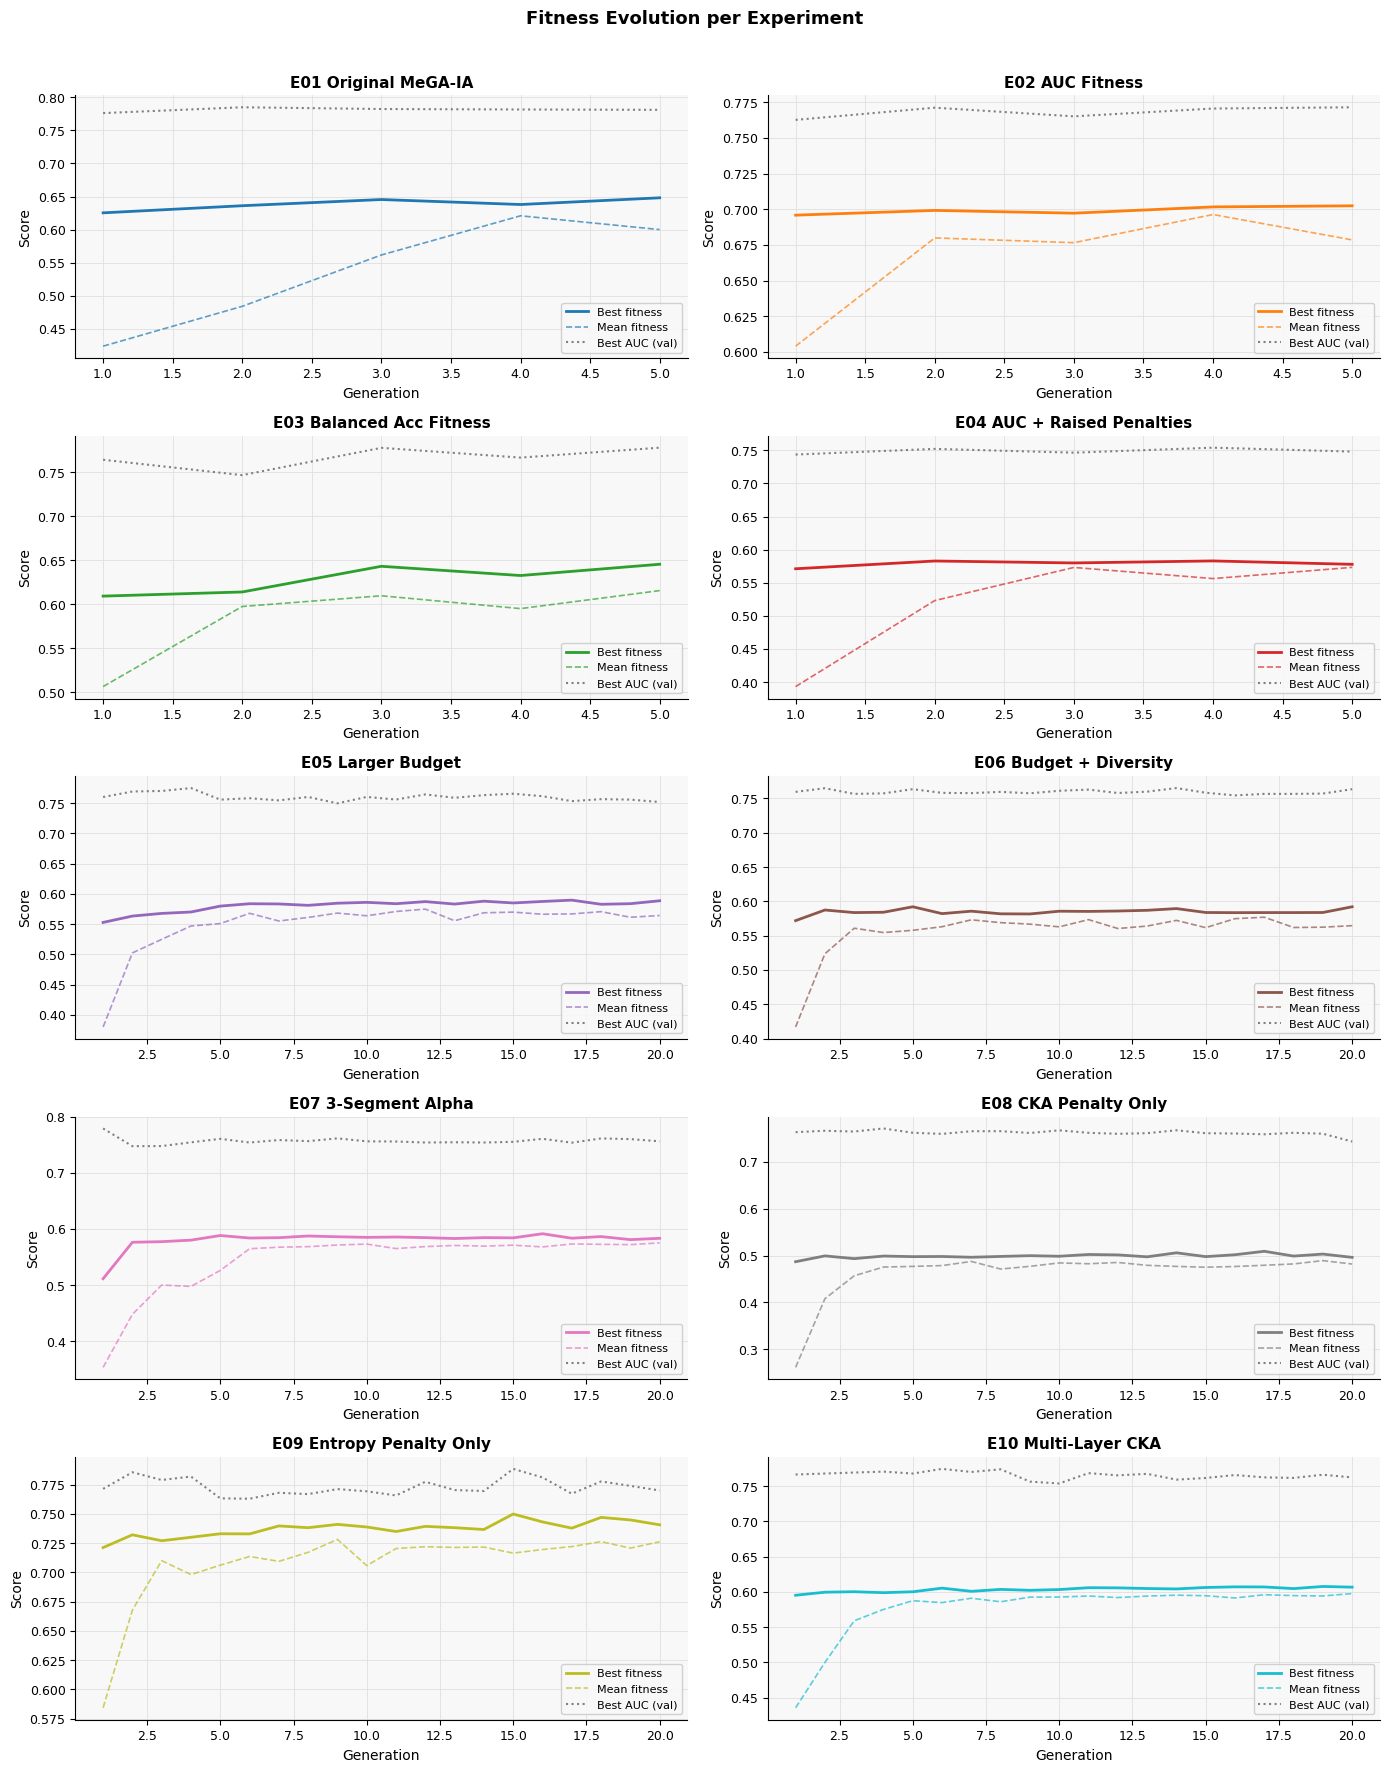

[14:30:28] ✅ Figure 1 saved: fitness curves.
[14:30:28] 🔷 Generating Figure 2: Validation metric evolution...


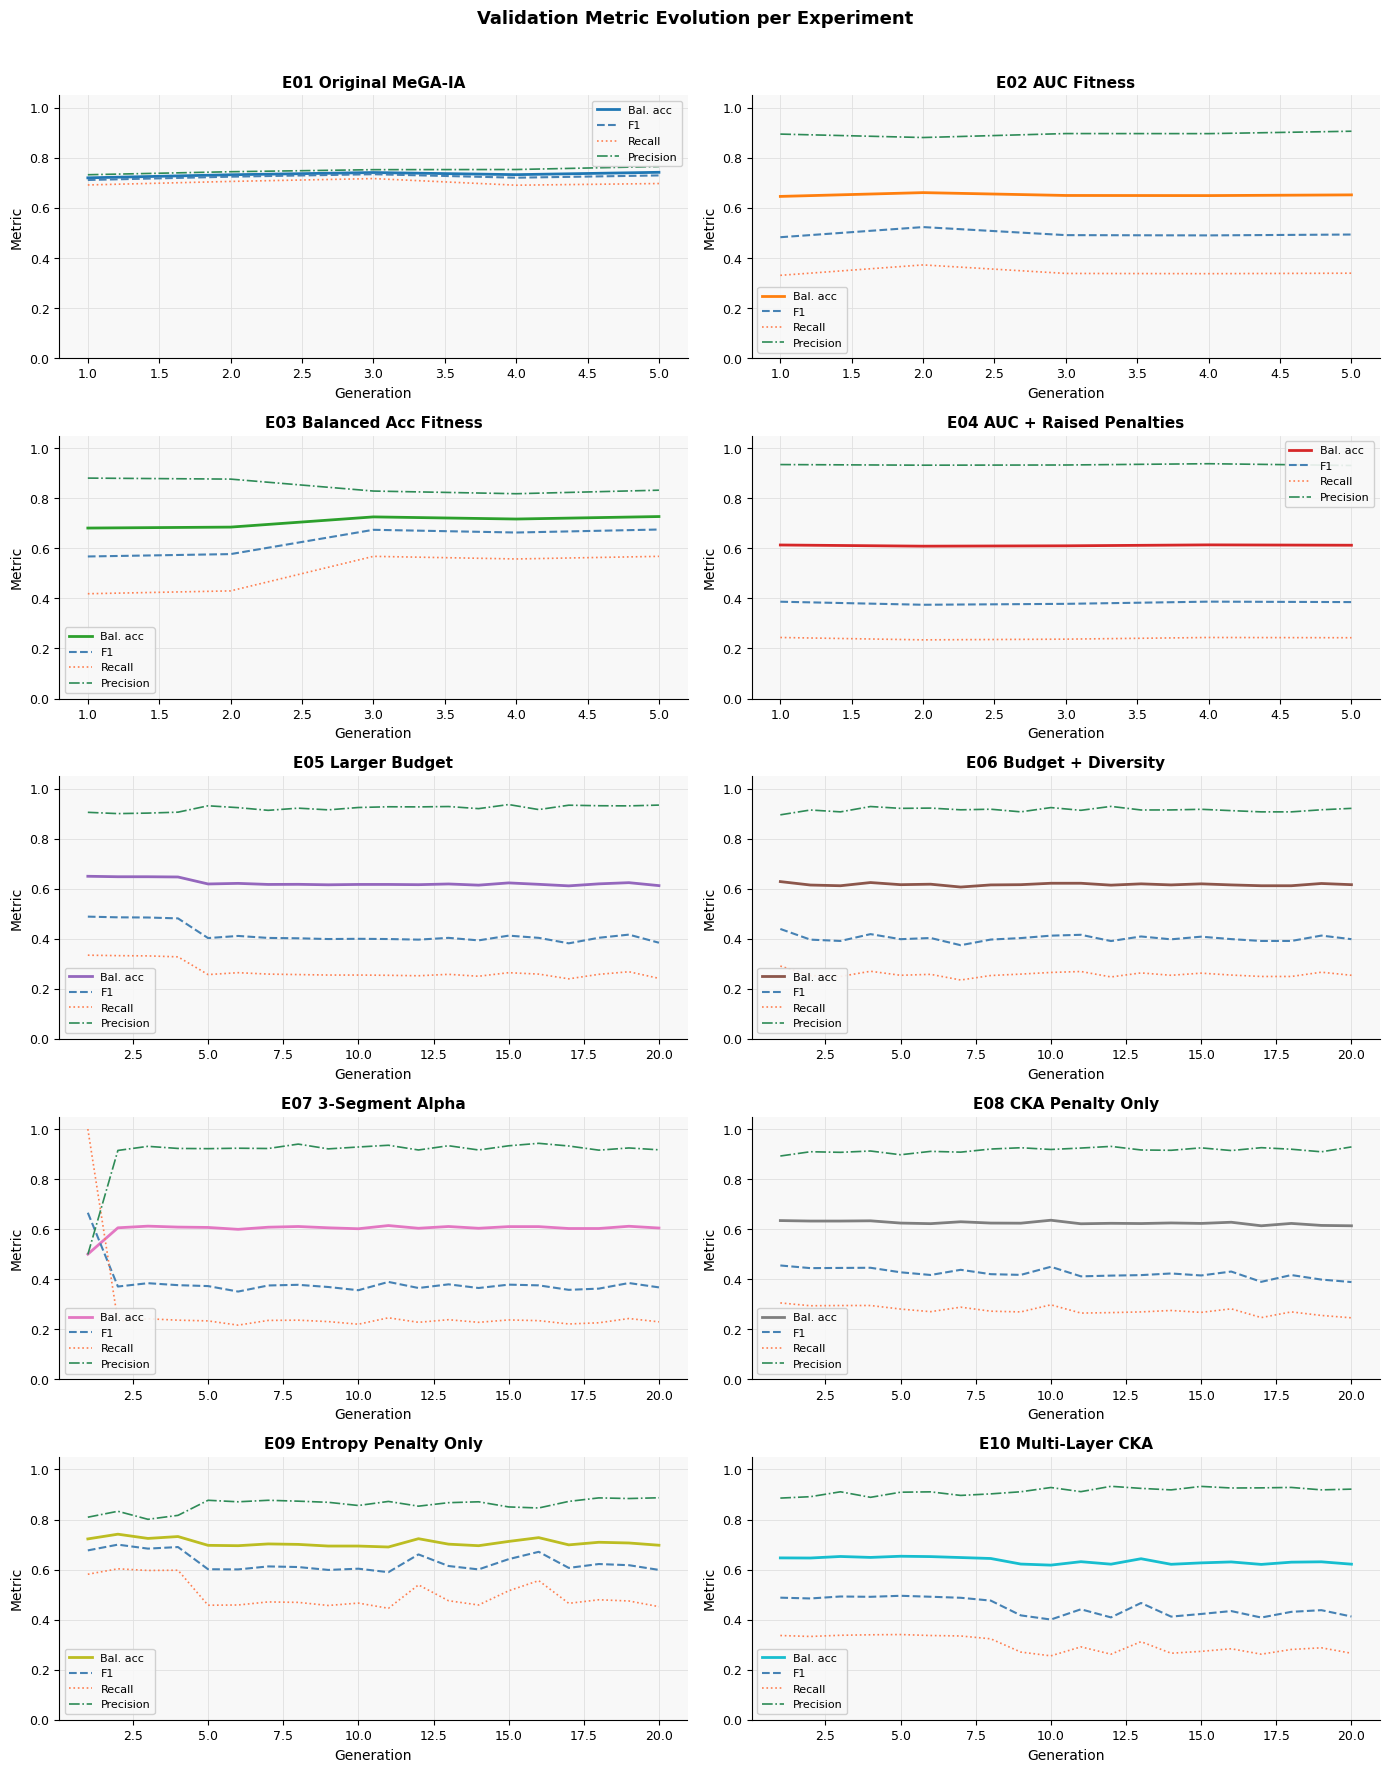

[14:30:32] ✅ Figure 2 saved: val metric curves.
[14:30:32] 🔷 Generating Figure 3: Test set comparison bars...


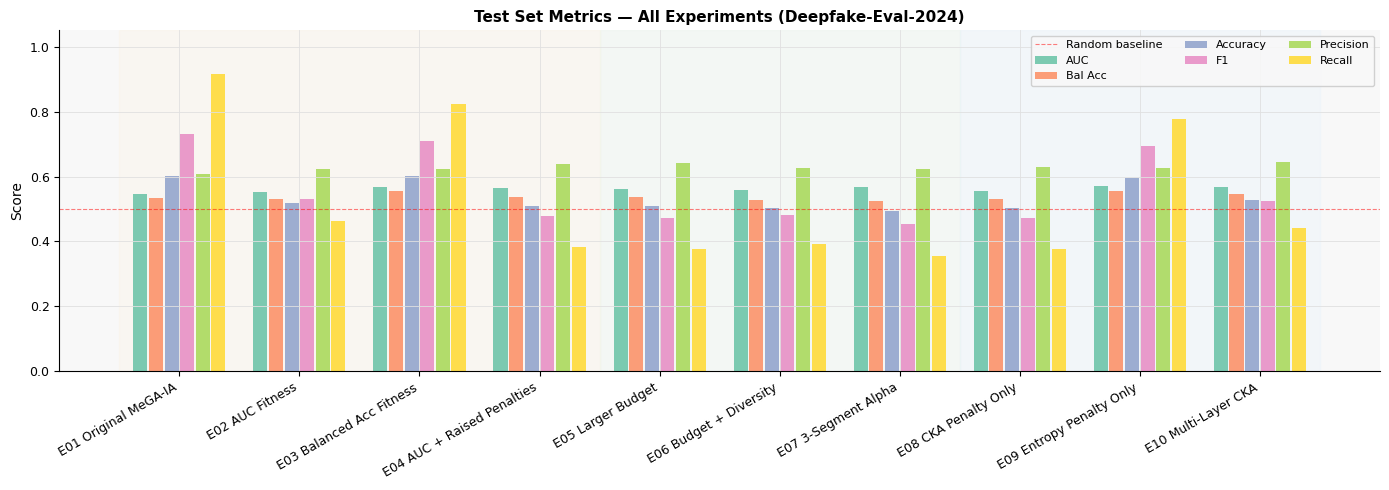

[14:30:32] ✅ Figure 3 saved: test comparison bars.
[14:30:32] 🔷 Generating Figure 4: ROC curves...


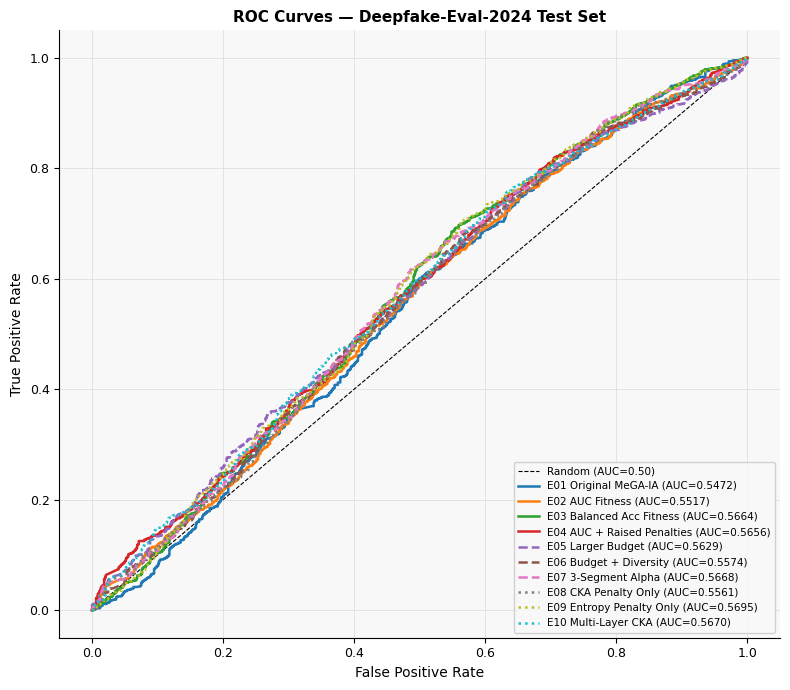

[14:30:33] ✅ Figure 4 saved: ROC curves.
[14:30:33] 🔷 Generating Figure 5: Confusion matrices...


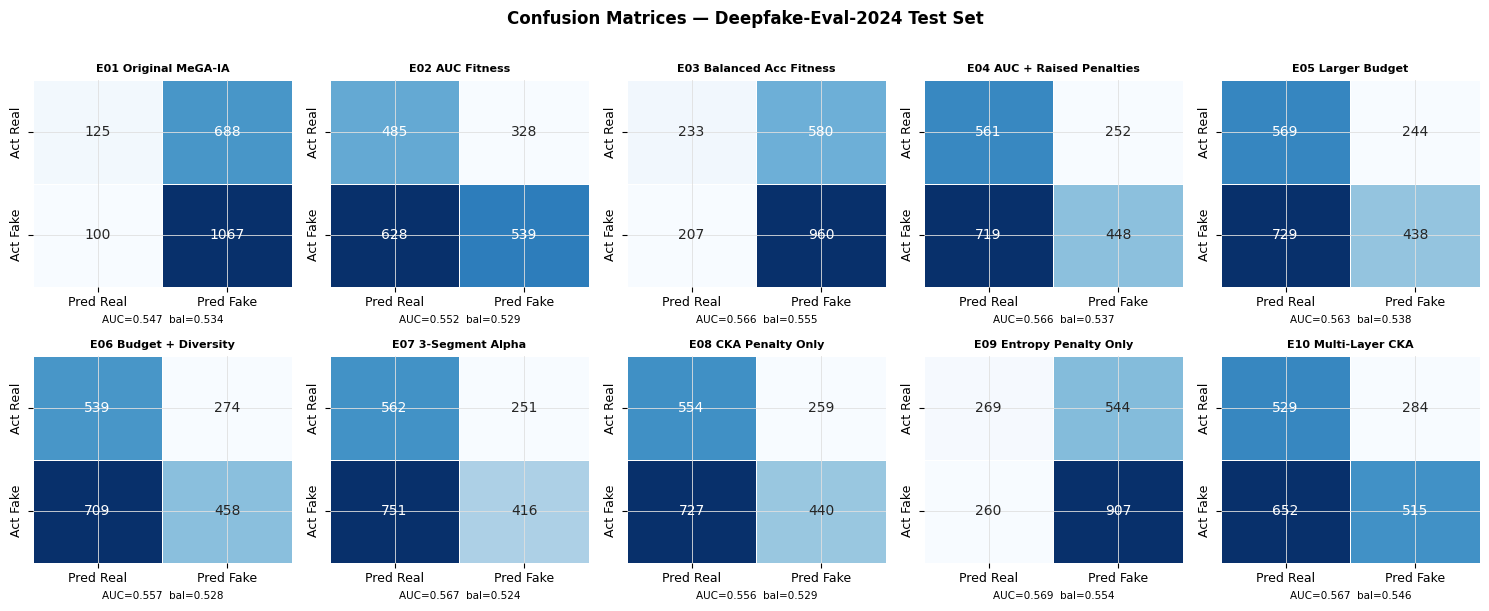

[14:30:36] ✅ Figure 5 saved: confusion matrices.
[14:30:36] 🔷 Generating Figure 6: Diversity + mean AUC...


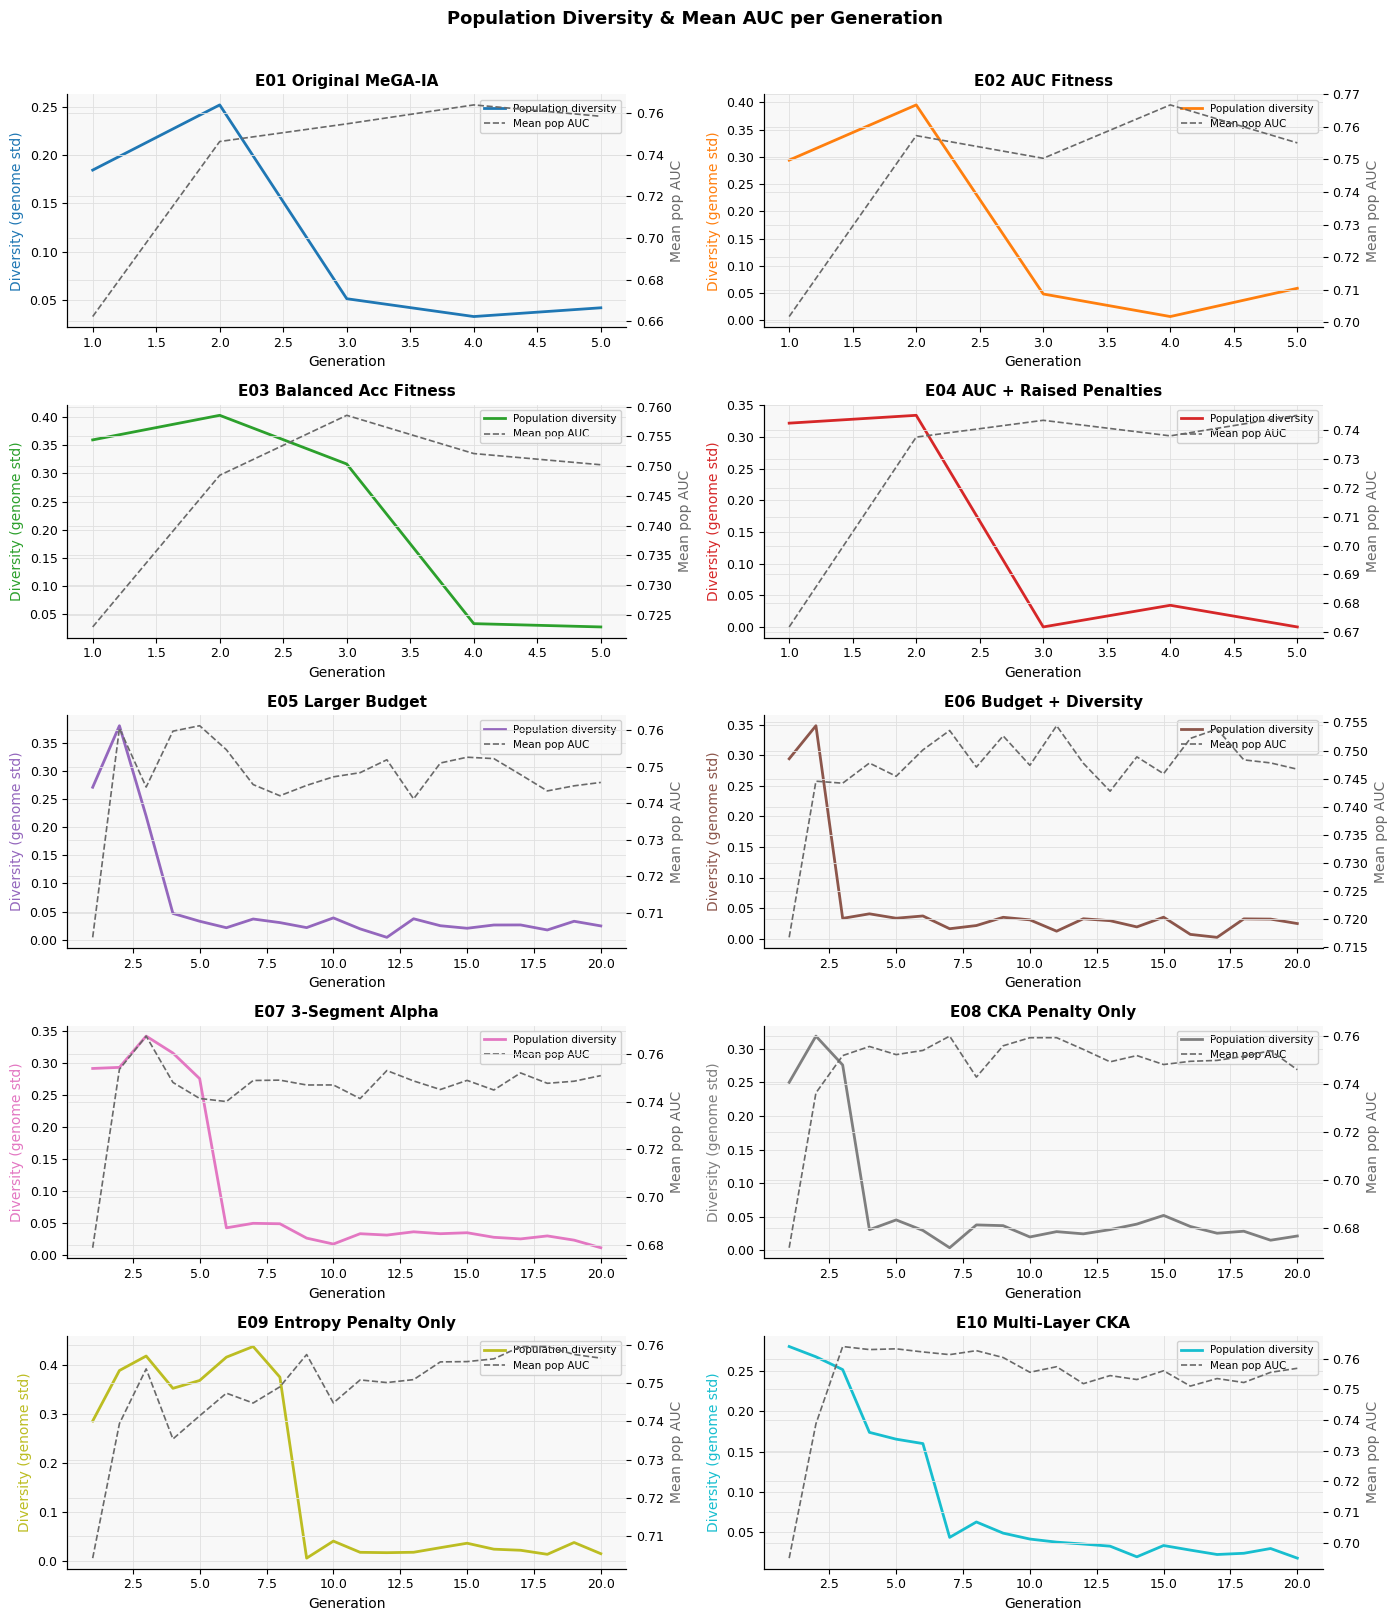

[14:30:42] ✅ Figure 6 saved: diversity curves.


In [ ]:
log('Generating Figure 1: Fitness evolution curves...', 'HEAD')
fig_fitness_curves()

log('Generating Figure 2: Validation metric evolution...', 'HEAD')
fig_val_metrics_evolution()

log('Generating Figure 3: Test set comparison bars...', 'HEAD')
fig_test_comparison()

log('Generating Figure 4: ROC curves...', 'HEAD')
fig_roc_curves()

log('Generating Figure 5: Confusion matrices...', 'HEAD')
fig_confusion_matrices()

log('Generating Figure 6: Diversity + mean AUC...', 'HEAD')
fig_diversity_and_cka()


## Final Summary

In [ ]:
print()
print('=' * 110)
print(f'  FINAL RESULTS SUMMARY — MeGA-IA Experiments vs Deepfake-Eval-2024 Test Set')
print('=' * 110)
print(f'  {"Experiment":<30} {"Group":<25} {"AUC":>6} {"BalAcc":>7} {"Acc":>6} '
      f'{"F1":>6} {"Prec":>6} {"Rec":>6}  {"Val AUC":>8}')
print('─' * 110)

# Sort by test AUC descending (show best first)
ranked = sorted(
    [cfg for cfg in EXPERIMENTS if cfg['id'] in test_results],
    key=lambda c: test_results[c['id']]['auc'], reverse=True
)

RANK_ICONS = ['🥇', '🥈', '🥉']
for rank, cfg in enumerate(ranked):
    eid = cfg['id']
    tm  = test_results[eid]
    vm  = completed_results.get(eid, {}).get('best_val_metrics', {})
    icon = RANK_ICONS[rank] if rank < 3 else f'  {rank+1}.'
    print(f'{icon} {cfg["name"]:<28} {cfg["group"]:<25} '
          f'{tm["auc"]:>6.4f} {tm["bal_acc"]:>7.4f} {tm["accuracy"]:>6.4f} '
          f'{tm["f1"]:>6.4f} {tm["precision"]:>6.4f} {tm["recall"]:>6.4f}  '
          f'{vm.get("auc", float("nan")):>8.4f}')

print('─' * 110)

# ── Best experiment ──────────────────────────────────────────────────────────
if ranked:
    best = ranked[0]
    bm   = test_results[best['id']]
    print()
    print('🏆 BEST EXPERIMENT:', best['name'])
    print(f'   Config : {best["description"]}')
    print(f'   Test   : AUC={bm["auc"]:.4f}  BalAcc={bm["bal_acc"]:.4f}  '
          f'Acc={bm["accuracy"]:.4f}  F1={bm["f1"]:.4f}')
    print(f'   TP={bm["tp"]}  TN={bm["tn"]}  FP={bm["fp"]}  FN={bm["fn"]}')

# ── Tier-level analysis ──────────────────────────────────────────────────────
print()
print('── PER-TIER BEST PERFORMANCE ─────────────────────────────────────────────')
tiers = {}
for cfg in EXPERIMENTS:
    eid = cfg['id']
    if eid not in test_results: continue
    grp = cfg['group']
    auc_val = test_results[eid]['auc']
    if grp not in tiers or auc_val > tiers[grp]['auc']:
        tiers[grp] = {'name': cfg['name'], 'auc': auc_val,
                      'bal': test_results[eid]['bal_acc'],
                      'f1':  test_results[eid]['f1']}

for grp, info in tiers.items():
    print(f'  {grp:<30}  best={info["name"]:<28}  '
          f'AUC={info["auc"]:.4f}  bal={info["bal"]:.4f}  F1={info["f1"]:.4f}')

# ── Biggest improvement from each change ───────────────────────────────────
print()
print('── IMPACT ANALYSIS ──────────────────────────────────────────────────────')
base_auc = test_results.get('E01_original', {}).get('auc', float('nan'))
print(f'  Baseline (E01 original MeGA-IA) test AUC: {base_auc:.4f}')
print()
for cfg in EXPERIMENTS[1:]:
    eid = cfg['id']
    if eid not in test_results: continue
    delta = test_results[eid]['auc'] - base_auc
    sign  = '+' if delta >= 0 else ''
    bar   = '█' * int(abs(delta) * 200)
    print(f'  {cfg["name"]:<35}  ΔAUC={sign}{delta:.4f}  {bar}')

print()
print('── CHECKPOINTED FILES ────────────────────────────────────────────────────')
for f in sorted(os.listdir(CHECKPOINT_DIR)):
    fpath = os.path.join(CHECKPOINT_DIR, f)
    print(f'  {f:<55}  {os.path.getsize(fpath)/1e3:>8.1f} KB')

print()
print('=' * 110)
print('  All figures saved to:', CHECKPOINT_DIR)
print('=' * 110)



  FINAL RESULTS SUMMARY — MeGA-IA Experiments vs Deepfake-Eval-2024 Test Set
  Experiment                     Group                        AUC  BalAcc    Acc     F1   Prec    Rec   Val AUC
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
🥇 E09 Entropy Penalty Only     Tier 3 — Penalty Ablation 0.5695  0.5540 0.5939 0.6929 0.6251 0.7772    0.7885
🥈 E10 Multi-Layer CKA          Tier 3 — Penalty Ablation 0.5670  0.5460 0.5273 0.5239 0.6446 0.4413    0.7662
🥉 E07 3-Segment Alpha          Tier 2 — Search Budget    0.5668  0.5239 0.4939 0.4537 0.6237 0.3565    0.7605
  4. E03 Balanced Acc Fitness     Tier 1 — Fitness          0.5664  0.5546 0.6025 0.7093 0.6234 0.8226    0.7777
  5. E04 AUC + Raised Penalties   Tier 1 — Fitness          0.5656  0.5370 0.5096 0.4799 0.6400 0.3839    0.7540
  6. E05 Larger Budget            Tier 2 — Search Budget    0.5629  0.5376 0.5086 0.4738 0.6422 0.3753    0.7535
  7. E06 Budget + Diversity   